# Sales Performance Analysis — BCA Data Analytics Test Project

**Dataset:** `BCA_Data_Analytics_Test_Project.xlsx` (3 sheets: Orders, Customers, Products) — calendar year 2025

**Objective:** Clean the raw sales data, validate it, and analyse sales, profitability, customers, products,
salespeople and receivables to give management actionable recommendations.

**Workflow**
1. Load data
2. Data understanding
3. Data quality checks
4. Data cleaning & feature engineering
5. Export cleaned dataset (CSV / Excel / SQLite for SQL queries)
6. Exploratory analysis & KPIs
7. Key insights & recommendations

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.width", 140)

DATA_DIR = Path("data")
CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)
RAW_FILE = DATA_DIR / "BCA_Data_Analytics_Test_Project.xlsx"

# Consistent chart style
PRIMARY, ACCENT, MUTED, NEG = "#1F4E79", "#E07A1F", "#9DB4CC", "#C0392B"
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25,
    "axes.titleweight": "bold", "axes.titlesize": 12, "font.size": 10,
})
lakh = mtick.FuncFormatter(lambda v, _: f"₹{v/1e5:,.1f}L")

def save(fig, name):
    fig.tight_layout()
    fig.savefig(CHART_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 1. Load data

In [2]:
sheets = pd.read_excel(RAW_FILE, sheet_name=None)
orders_raw = sheets["Orders"].copy()
customers = sheets["Customers"].copy()
products = sheets["Products"].copy()

for name, df in [("Orders", orders_raw), ("Customers", customers), ("Products", products)]:
    print(f"{name:<10} rows={df.shape[0]:>5}  cols={df.shape[1]}")

Orders     rows= 1200  cols=15
Customers  rows=   80  cols=5
Products   rows=   25  cols=5


## 2. Data understanding

In [3]:
orders_raw.head()

,order_id,order_date,customer_id,product_id,quantity,discount_pct,payment_status,salesperson,unit_cost,selling_price,gross_sales,discount_amount,net_sales,cost,profit
0,O00001,2025-08-14,C049,P006,18,5,Pending,Neha,"1,677.16","2,182.12","39,278.16","1,963.91","37,314.25","30,188.88","7,125.37"
1,O00002,2025-10-04,C003,P012,6,5,Paid,Neha,"2,251.26","2,763.16","16,578.96",828.95,"15,750.01","13,507.56","2,242.45"
2,O00003,2025-10-13,C045,P009,2,5,Paid,Imran,"1,361.75","1,625.94","3,251.88",162.59,"3,089.29","2,723.50",365.79
3,O00004,2025-04-07,C014,P013,15,8,Overdue,Imran,"2,259.01","3,086.58","46,298.70","3,703.90","42,594.80","33,885.15","8,709.65"
4,O00005,2025-10-11,C030,P004,14,5,Pending,Amit,"2,203.16","2,471.22","34,597.08","1,729.85","32,867.23","30,844.24","2,022.99"


In [4]:
orders_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         1200 non-null   object        
 1   order_date       1200 non-null   datetime64[ns]
 2   customer_id      1200 non-null   object        
 3   product_id       1200 non-null   object        
 4   quantity         1200 non-null   int64         
 5   discount_pct     1200 non-null   int64         
 6   payment_status   1200 non-null   object        
 7   salesperson      1200 non-null   object        
 8   unit_cost        1199 non-null   float64       
 9   selling_price    1199 non-null   float64       
 10  gross_sales      1199 non-null   float64       
 11  discount_amount  1199 non-null   float64       
 12  net_sales        1199 non-null   float64       
 13  cost             1199 non-null   float64       
 14  profit           1199 non-null   float64

In [5]:
orders_raw.describe().T

,count,mean,min,25%,50%,75%,max,std
order_date,1200,2025-07-01 13:42:00,2025-01-01 00:00:00,2025-04-05 00:00:00,2025-06-29 00:00:00,2025-10-04 00:00:00,2025-12-31 00:00:00,NaN
quantity,"1,200.00",10.79,-3.00,6.00,11.00,16.00,20.00,5.80
discount_pct,"1,200.00",6.22,0.00,2.00,5.00,8.00,35.00,4.34
unit_cost,"1,199.00","1,475.96",283.62,900.45,"1,612.11","2,226.75","2,317.76",699.85
selling_price,"1,199.00","1,882.67",365.85,"1,016.77","2,055.59","2,590.72","3,188.71",908.54
gross_sales,"1,199.00","20,573.27","-6,166.77","6,542.08","16,585.02","32,311.90","63,774.20","15,893.16"
discount_amount,"1,199.00","1,294.07",-493.34,184.63,741.37,"1,921.37","17,478.85","1,572.95"
net_sales,"1,199.00","19,279.21","-5,673.43","6,195.28","15,755.77","29,813.18","63,774.20","14,944.49"
cost,"1,199.00","16,120.25","-4,642.68","5,322.24","13,360.50","25,495.36","46,355.20","12,336.82"
profit,"1,199.00","3,158.95","-4,577.53",738.36,"2,081.50","4,550.83","18,684.20","3,241.33"


In [6]:
for col in ["payment_status", "salesperson"]:
    print(col, "->", orders_raw[col].value_counts().to_dict())
print("customer_type ->", customers["customer_type"].value_counts().to_dict())
print("city ->", customers["city"].value_counts().to_dict())
print("category ->", products["category"].value_counts().to_dict())
print("Order date range:", orders_raw["order_date"].min().date(), "to", orders_raw["order_date"].max().date())

payment_status -> {'Paid': 824, 'Pending': 249, 'Overdue': 126, 'pending': 1}
salesperson -> {'Amit': 264, 'Rahul': 250, 'Imran': 243, 'Neha': 222, 'Sana': 221}
customer_type -> {'Retailer': 40, 'Wholesaler': 23, 'Corporate': 17}
city -> {'Varanasi': 15, 'Jaipur': 11, 'Delhi': 10, 'Prayagraj': 10, 'Kanpur': 10, 'Patna': 9, 'Noida': 8, 'Lucknow': 7}
category -> {'Hardware': 8, 'Paint': 7, 'Electrical': 5, 'Plumbing': 3, 'Safety': 2}
Order date range: 2025-01-01 to 2025-12-31


## 3. Data quality checks
Each check below looks for a specific type of problem. The summary table at the end lists every issue found.

In [7]:
o = orders_raw
checks = {}

# 3.1 Missing values
checks["Missing values (any column)"] = o[o.isna().any(axis=1)]["order_id"].tolist()

# 3.2 Duplicates
checks["Duplicate order_id"] = o[o["order_id"].duplicated()]["order_id"].tolist()
checks["Fully duplicated rows"] = o[o.duplicated()]["order_id"].tolist()

# 3.3 Inconsistent text categories
valid_status = {"Paid", "Pending", "Overdue"}
checks["Invalid payment_status spelling/case"] = o[~o["payment_status"].isin(valid_status)]["order_id"].tolist()

# 3.4 Invalid / outlier numeric values
checks["Quantity <= 0"] = o[o["quantity"] <= 0]["order_id"].tolist()
q1, q3 = o["discount_pct"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
checks[f"Discount outlier (> {upper:.0f}% IQR fence)"] = o[o["discount_pct"] > upper]["order_id"].tolist()

# 3.5 Referential integrity (foreign keys)
checks["customer_id not in Customers"] = o[~o["customer_id"].isin(customers["customer_id"])]["order_id"].tolist()
checks["product_id not in Products"] = o[~o["product_id"].isin(products["product_id"])]["order_id"].tolist()

# 3.6 Calculation consistency (should all be empty)
tol = 0.01
checks["gross_sales != qty x price"] = o[(o["quantity"] * o["selling_price"] - o["gross_sales"]).abs() > tol]["order_id"].tolist()
checks["net_sales != gross - discount"] = o[(o["gross_sales"] - o["discount_amount"] - o["net_sales"]).abs() > tol]["order_id"].tolist()
checks["profit != net - cost"] = o[(o["net_sales"] - o["cost"] - o["profit"]).abs() > tol]["order_id"].tolist()

# 3.7 Dates
checks["Order date outside 2025"] = o[o["order_date"].dt.year != 2025]["order_id"].tolist()

dq = pd.DataFrame(
    [(k, len(v), ", ".join(v) if v else "-") for k, v in checks.items()],
    columns=["Check", "Rows affected", "Order IDs"],
)
dq

,Check,Rows affected,Order IDs
0,Missing values (any column),1,O00056
1,Duplicate order_id,0,-
2,Fully duplicated rows,0,-
3,Invalid payment_status spelling/case,1,O00076
4,Quantity <= 0,1,O00011
5,Discount outlier (> 17% IQR fence),1,O00026
6,customer_id not in Customers,1,O00041
7,product_id not in Products,1,O00056
8,gross_sales != qty x price,0,-
9,net_sales != gross - discount,0,-


In [8]:
issue_ids = sorted({i for v in checks.values() for i in v})
orders_raw[orders_raw["order_id"].isin(issue_ids)]

,order_id,order_date,customer_id,product_id,quantity,discount_pct,payment_status,salesperson,unit_cost,selling_price,gross_sales,discount_amount,net_sales,cost,profit
10,O00011,2025-07-11,C048,P025,-3,8,Pending,Rahul,"1,547.56","2,055.59","-6,166.77",-493.34,"-5,673.43","-4,642.68","-1,030.75"
25,O00026,2025-04-05,C056,P007,18,35,Pending,Neha,"2,057.68","2,774.42","49,939.56","17,478.85","32,460.71","37,038.24","-4,577.53"
40,O00041,2025-11-19,C999,P017,18,15,Paid,Amit,"1,836.81","2,401.71","43,230.78","6,484.62","36,746.16","33,062.58","3,683.58"
55,O00056,2025-02-08,C062,P999,8,10,Paid,Rahul,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75,O00076,2025-08-03,C025,P005,8,15,pending,Imran,704.22,826.10,"6,608.80",991.32,"5,617.48","5,633.76",-16.28


## 4. Data cleaning

| # | Issue | Order | Decision | Reason |
|---|---|---|---|---|
| 1 | `payment_status` = `pending` (lower-case) | O00076 | Standardise to Title case (`Pending`) | Same category written differently would split counts |
| 2 | `product_id` = `P999` not in Products, all price/sales/profit fields blank | O00056 | **Remove** | No product, price or revenue exists, so it cannot be analysed or reliably imputed |
| 3 | `quantity` = -3 (negative sales & profit) | O00011 | **Remove** | Physically invalid quantity; likely a data-entry error or unrecorded return |
| 4 | `customer_id` = `C999` not in Customers | O00041 | **Keep**, customer fields set to `Unknown` | Sales and profit values are valid, so removing it would understate revenue |
| 5 | `discount_pct` = 35% (all others 0–20%) | O00026 | **Keep**, flag as `discount_outlier` | A real transaction that made a loss; it is a business issue to report, not a data error |

All numeric calculations (gross, net, cost, profit) were verified above and are consistent, so no values were recalculated.

In [9]:
df = orders_raw.copy()
log = []

# 1. Standardise text columns
df["payment_status"] = df["payment_status"].str.strip().str.title()
df["salesperson"] = df["salesperson"].str.strip().str.title()
log.append(("Standardised payment_status / salesperson text", 0))

# 2. Remove order with unknown product and missing financials
mask = ~df["product_id"].isin(products["product_id"])
log.append(("Removed orders with unknown product_id (missing financials)", int(mask.sum())))
df = df[~mask]

# 3. Remove invalid quantity
mask = df["quantity"] <= 0
log.append(("Removed orders with quantity <= 0", int(mask.sum())))
df = df[~mask]

# 4 & 5. Flags
df["unknown_customer"] = ~df["customer_id"].isin(customers["customer_id"])
df["discount_outlier"] = df["discount_pct"] > 20

pd.DataFrame(log, columns=["Step", "Rows removed"])

,Step,Rows removed
0,Standardised payment_status / salesperson text,0
1,Removed orders with unknown product_id (missin...,1
2,Removed orders with quantity <= 0,1


### 4.1 Feature engineering & merge with master tables

In [10]:
df = (
    df.merge(customers[["customer_id", "customer_name", "city", "customer_type"]], on="customer_id", how="left")
      .merge(products[["product_id", "product_name", "category"]], on="product_id", how="left")
)
for c in ["customer_name", "city", "customer_type"]:
    df[c] = df[c].fillna("Unknown")

df["order_month_num"] = df["order_date"].dt.month
df["order_month"] = df["order_date"].dt.strftime("%b")
df["year_month"] = df["order_date"].dt.strftime("%Y-%m")
df["quarter"] = "Q" + df["order_date"].dt.quarter.astype(str)
df["profit_margin_pct"] = (df["profit"] / df["net_sales"] * 100).round(2)
df["is_loss"] = df["profit"] < 0
df["discount_band"] = pd.cut(df["discount_pct"], bins=[-1, 0, 5, 10, 100],
                             labels=["0%", "1-5%", "6-10%", ">10%"]).astype(str)

money = ["unit_cost", "selling_price", "gross_sales", "discount_amount", "net_sales", "cost", "profit"]
df[money] = df[money].round(2)

cols = ["order_id", "order_date", "year_month", "order_month_num", "order_month", "quarter",
        "customer_id", "customer_name", "city", "customer_type",
        "product_id", "product_name", "category", "salesperson", "payment_status",
        "quantity", "unit_cost", "selling_price", "discount_pct", "discount_band",
        "gross_sales", "discount_amount", "net_sales", "cost", "profit", "profit_margin_pct",
        "is_loss", "unknown_customer", "discount_outlier"]
clean = df[cols].sort_values("order_id").reset_index(drop=True)
print("Cleaned shape:", clean.shape)
clean.head()

Cleaned shape: (1198, 29)


,order_id,order_date,year_month,order_month_num,order_month,quarter,customer_id,customer_name,city,customer_type,...,discount_band,gross_sales,discount_amount,net_sales,cost,profit,profit_margin_pct,is_loss,unknown_customer,discount_outlier
0,O00001,2025-08-14,2025-08,8,Aug,Q3,C049,Customer 49,Noida,Corporate,...,1-5%,"39,278.16","1,963.91","37,314.25","30,188.88","7,125.37",19.10,False,False,False
1,O00002,2025-10-04,2025-10,10,Oct,Q4,C003,Customer 3,Delhi,Retailer,...,1-5%,"16,578.96",828.95,"15,750.01","13,507.56","2,242.45",14.24,False,False,False
2,O00003,2025-10-13,2025-10,10,Oct,Q4,C045,Customer 45,Varanasi,Retailer,...,1-5%,"3,251.88",162.59,"3,089.29","2,723.50",365.79,11.84,False,False,False
3,O00004,2025-04-07,2025-04,4,Apr,Q2,C014,Customer 14,Prayagraj,Corporate,...,6-10%,"46,298.70","3,703.90","42,594.80","33,885.15","8,709.65",20.45,False,False,False
4,O00005,2025-10-11,2025-10,10,Oct,Q4,C030,Customer 30,Varanasi,Corporate,...,1-5%,"34,597.08","1,729.85","32,867.23","30,844.24","2,022.99",6.16,False,False,False


### 4.2 Validate the cleaned data

In [11]:
assert clean["order_id"].is_unique
assert clean[money].notna().all().all()
assert (clean["quantity"] > 0).all()
assert set(clean["payment_status"]) == {"Paid", "Pending", "Overdue"}
assert clean["product_id"].isin(products["product_id"]).all()
print(f"All validation checks passed. Rows: raw={len(orders_raw)} -> clean={len(clean)} "
      f"({len(orders_raw) - len(clean)} removed)")

All validation checks passed. Rows: raw=1200 -> clean=1198 (2 removed)


## 5. Export cleaned dataset

In [12]:
clean.to_csv(DATA_DIR / "cleaned_data.csv", index=False)

with pd.ExcelWriter(DATA_DIR / "cleaned_data.xlsx") as xw:
    clean.to_excel(xw, sheet_name="Orders_Clean", index=False)
    customers.to_excel(xw, sheet_name="Customers", index=False)
    products.to_excel(xw, sheet_name="Products", index=False)
    dq.to_excel(xw, sheet_name="Data_Quality_Log", index=False)

# SQLite database used by queries.sql
db_path = DATA_DIR / "sales.db"
db_path.unlink(missing_ok=True)
with sqlite3.connect(db_path) as con:
    raw_sql = orders_raw.assign(order_date=orders_raw["order_date"].dt.strftime("%Y-%m-%d"))
    raw_sql.to_sql("orders_raw", con, index=False)
    clean_orders = clean[["order_id", "order_date", "customer_id", "product_id", "quantity", "discount_pct",
                          "payment_status", "salesperson", "unit_cost", "selling_price", "gross_sales",
                          "discount_amount", "net_sales", "cost", "profit"]]
    clean_orders.assign(order_date=clean_orders["order_date"].dt.strftime("%Y-%m-%d")).to_sql("orders", con, index=False)
    customers.assign(join_date=customers["join_date"].dt.strftime("%Y-%m-%d")).to_sql("customers", con, index=False)
    products.to_sql("products", con, index=False)

print("Saved: data/cleaned_data.csv, data/cleaned_data.xlsx, data/sales.db")

Saved: data/cleaned_data.csv, data/cleaned_data.xlsx, data/sales.db


## 6. Exploratory analysis

### 6.1 Headline KPIs

In [13]:
kpi = {
    "Total orders": len(clean),
    "Units sold": clean["quantity"].sum(),
    "Gross sales (₹)": clean["gross_sales"].sum(),
    "Discount given (₹)": clean["discount_amount"].sum(),
    "Net sales (₹)": clean["net_sales"].sum(),
    "Total cost (₹)": clean["cost"].sum(),
    "Profit (₹)": clean["profit"].sum(),
    "Profit margin (%)": clean["profit"].sum() / clean["net_sales"].sum() * 100,
    "Avg order value (₹)": clean["net_sales"].mean(),
    "Active customers": clean["customer_id"].nunique(),
    "Loss-making orders": int(clean["is_loss"].sum()),
}
pd.Series(kpi).to_frame("Value")

,Value
Total orders,"1,198.00"
Units sold,"12,939.00"
Gross sales (₹),"24,673,519.92"
Discount given (₹),"1,552,077.96"
Net sales (₹),"23,121,442.00"
Total cost (₹),"19,332,826.36"
Profit (₹),"3,788,615.80"
Profit margin (%),16.39
Avg order value (₹),"19,300.04"
Active customers,81.00


### 6.2 Monthly sales & profit trend

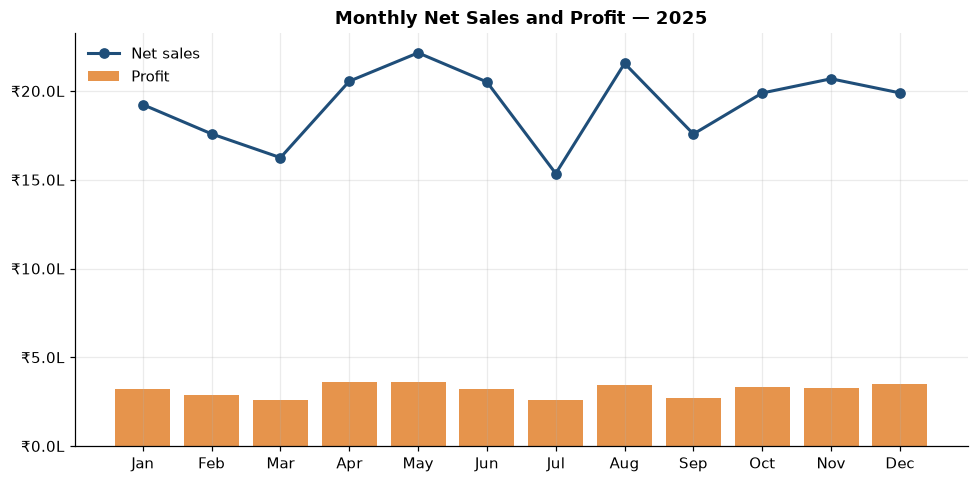

,order_month_num,order_month,orders,net_sales,profit,margin_pct,mom_growth_pct
0,1,Jan,106,"1,923,260.30","320,510.87",16.66,NaN
1,2,Feb,96,"1,758,324.00","286,107.85",16.27,-8.58
2,3,Mar,83,"1,624,413.56","261,424.07",16.09,-7.62
3,4,Apr,110,"2,055,097.23","358,212.12",17.43,26.51
4,5,May,105,"2,214,968.97","360,671.83",16.28,7.78
5,6,Jun,103,"2,050,698.43","321,489.78",15.68,-7.42
6,7,Jul,80,"1,534,993.87","259,315.75",16.89,-25.15
7,8,Aug,112,"2,155,393.85","343,213.78",15.92,40.42
8,9,Sep,96,"1,757,583.91","271,341.74",15.44,-18.46
9,10,Oct,109,"1,988,633.24","333,026.02",16.75,13.15


In [14]:
monthly = (clean.groupby(["order_month_num", "order_month"])
                .agg(orders=("order_id", "count"), net_sales=("net_sales", "sum"), profit=("profit", "sum"))
                .reset_index())
monthly["margin_pct"] = monthly["profit"] / monthly["net_sales"] * 100
monthly["mom_growth_pct"] = monthly["net_sales"].pct_change() * 100

fig, ax = plt.subplots()
ax.plot(monthly["order_month"], monthly["net_sales"], marker="o", color=PRIMARY, lw=2, label="Net sales")
ax.bar(monthly["order_month"], monthly["profit"], color=ACCENT, alpha=0.8, label="Profit")
ax.yaxis.set_major_formatter(lakh)
ax.set_title("Monthly Net Sales and Profit — 2025")
ax.legend(frameon=False)
save(fig, "01_monthly_trend")
monthly

### 6.3 Category performance

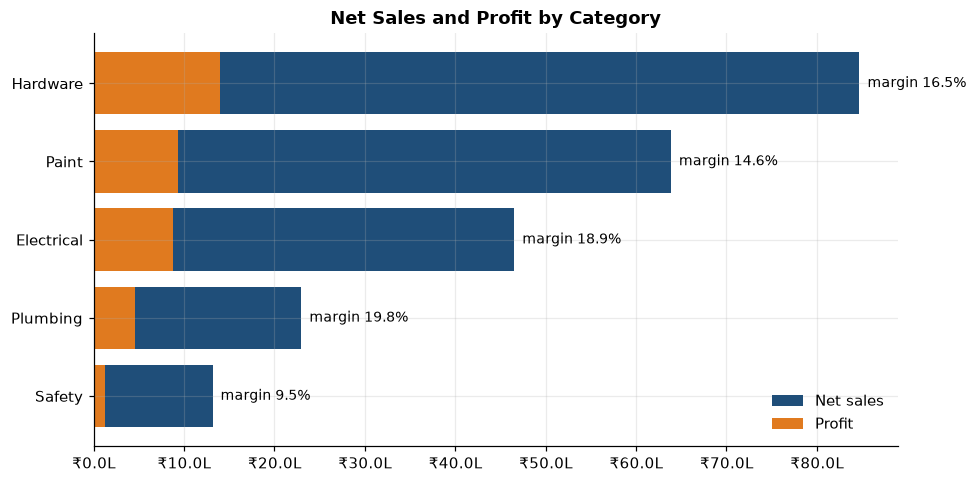

,orders,units,net_sales,profit,margin_pct,sales_share_pct
category,,,,,,
Hardware,383,4221,"8,471,034.87","1,397,715.92",16.50,36.64
Paint,325,3510,"6,385,185.90","931,642.82",14.59,27.62
Electrical,251,2711,"4,652,760.24","879,108.92",18.89,20.12
Plumbing,136,1461,"2,297,506.17","455,083.23",19.81,9.94
Safety,103,1036,"1,314,954.82","125,064.91",9.51,5.69


In [15]:
category = (clean.groupby("category")
                 .agg(orders=("order_id", "count"), units=("quantity", "sum"),
                      net_sales=("net_sales", "sum"), profit=("profit", "sum"))
                 .sort_values("net_sales", ascending=False))
category["margin_pct"] = category["profit"] / category["net_sales"] * 100
category["sales_share_pct"] = category["net_sales"] / category["net_sales"].sum() * 100

fig, ax = plt.subplots()
ax.barh(category.index[::-1], category["net_sales"][::-1], color=PRIMARY, label="Net sales")
ax.barh(category.index[::-1], category["profit"][::-1], color=ACCENT, label="Profit")
for y, (s, m) in enumerate(zip(category["net_sales"][::-1], category["margin_pct"][::-1])):
    ax.text(s, y, f"  margin {m:.1f}%", va="center", fontsize=9)
ax.xaxis.set_major_formatter(lakh)
ax.set_title("Net Sales and Profit by Category")
ax.legend(frameon=False, loc="lower right")
save(fig, "02_category")
category

### 6.4 Top & bottom products

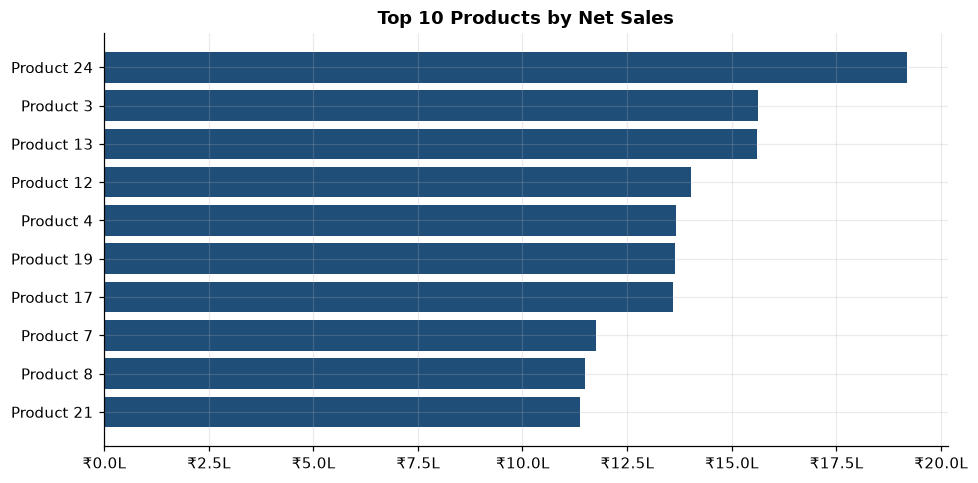

Top 10 by net sales


,product_id,product_name,category,units,net_sales,profit,margin_pct
23,P024,Product 24,Electrical,641,"1,920,049.81","474,915.31",24.73
2,P003,Product 3,Plumbing,535,"1,561,993.22","321,991.62",20.61
12,P013,Product 13,Hardware,539,"1,559,895.79","342,289.40",21.94
11,P012,Product 12,Paint,540,"1,402,027.38","186,346.98",13.29
3,P004,Product 4,Hardware,586,"1,367,029.45","75,977.70",5.56
18,P019,Product 19,Paint,532,"1,364,947.15","180,316.15",13.21
16,P017,Product 17,Hardware,606,"1,358,647.36","245,540.51",18.07
6,P007,Product 7,Paint,461,"1,175,854.68","227,264.21",19.33
7,P008,Product 8,Hardware,639,"1,149,980.51","240,306.53",20.90
20,P021,Product 21,Electrical,619,"1,137,481.34","126,208.66",11.10


Lowest 5 by profit margin


,product_id,product_name,category,units,net_sales,profit,margin_pct
3,P004,Product 4,Hardware,586,"1,367,029.45","75,977.70",5.56
0,P001,Product 1,Safety,484,"467,449.87","29,245.95",6.26
1,P002,Product 2,Paint,514,"196,343.28","14,073.74",7.17
17,P018,Product 18,Hardware,460,"1,119,786.93","84,322.33",7.53
4,P005,Product 5,Electrical,404,"314,083.26","29,578.38",9.42


In [16]:
product = (clean.groupby(["product_id", "product_name", "category"])
                .agg(units=("quantity", "sum"), net_sales=("net_sales", "sum"), profit=("profit", "sum"))
                .reset_index())
product["margin_pct"] = product["profit"] / product["net_sales"] * 100
top10 = product.nlargest(10, "net_sales")

fig, ax = plt.subplots()
ax.barh(top10["product_name"][::-1], top10["net_sales"][::-1], color=PRIMARY)
ax.xaxis.set_major_formatter(lakh)
ax.set_title("Top 10 Products by Net Sales")
save(fig, "03_top_products")

print("Top 10 by net sales"); display(top10)
print("Lowest 5 by profit margin"); display(product.nsmallest(5, "margin_pct"))

### 6.5 City & customer type

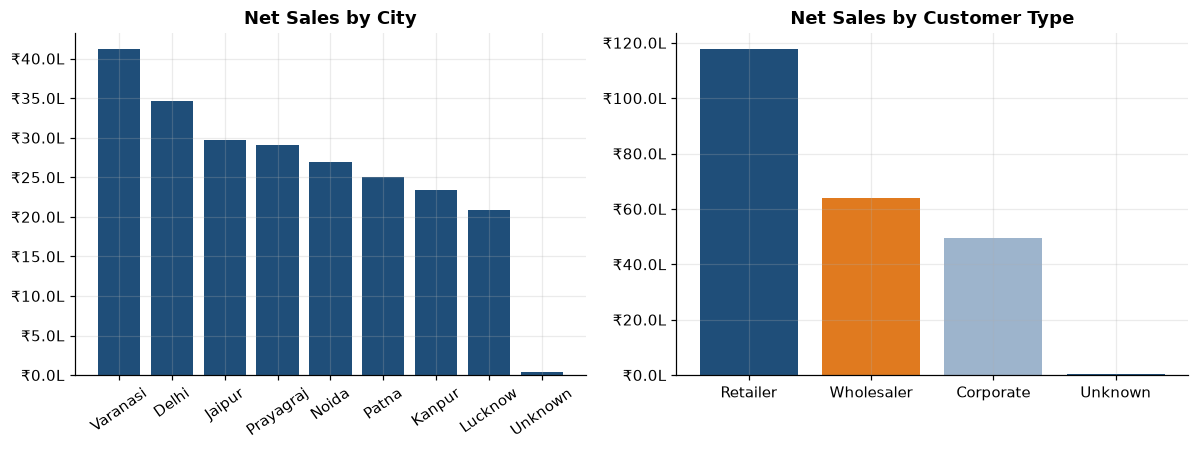

,customers,orders,net_sales,profit,margin_pct
city,,,,,
Varanasi,15,231,"4,115,607.99","643,013.45",15.62
Delhi,10,174,"3,469,617.82","549,947.93",15.85
Jaipur,11,148,"2,965,901.59","464,639.55",15.67
Prayagraj,10,141,"2,902,392.59","493,698.38",17.01
Noida,8,133,"2,696,051.72","450,841.31",16.72
Patna,9,131,"2,508,592.74","415,529.60",16.56
Kanpur,10,123,"2,334,294.88","398,415.16",17.07
Lucknow,7,116,"2,092,236.51","368,846.84",17.63
Unknown,1,1,"36,746.16","3,683.58",10.02


,customers,orders,net_sales,profit,avg_order_value,margin_pct
customer_type,,,,,,
Retailer,40,610,"11,759,153.75","1,954,106.85","19,277.30",16.62
Wholesaler,23,345,"6,378,340.72","1,010,486.75","18,487.94",15.84
Corporate,17,242,"4,947,201.37","820,338.62","20,442.98",16.58
Unknown,1,1,"36,746.16","3,683.58","36,746.16",10.02


In [17]:
city = (clean.groupby("city")
             .agg(customers=("customer_id", "nunique"), orders=("order_id", "count"),
                  net_sales=("net_sales", "sum"), profit=("profit", "sum"))
             .sort_values("net_sales", ascending=False))
city["margin_pct"] = city["profit"] / city["net_sales"] * 100

ctype = (clean.groupby("customer_type")
              .agg(customers=("customer_id", "nunique"), orders=("order_id", "count"),
                   net_sales=("net_sales", "sum"), profit=("profit", "sum"),
                   avg_order_value=("net_sales", "mean"))
              .sort_values("net_sales", ascending=False))
ctype["margin_pct"] = ctype["profit"] / ctype["net_sales"] * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(city.index, city["net_sales"], color=PRIMARY)
axes[0].yaxis.set_major_formatter(lakh); axes[0].set_title("Net Sales by City")
axes[0].tick_params(axis="x", rotation=35)
axes[1].bar(ctype.index, ctype["net_sales"], color=[PRIMARY, ACCENT, MUTED][:len(ctype)])
axes[1].yaxis.set_major_formatter(lakh); axes[1].set_title("Net Sales by Customer Type")
save(fig, "04_city_customer_type")
display(city); display(ctype)

### 6.6 Top customers

In [18]:
cust = (clean.groupby(["customer_id", "customer_name", "city", "customer_type"])
             .agg(orders=("order_id", "count"), net_sales=("net_sales", "sum"), profit=("profit", "sum"))
             .reset_index().sort_values("net_sales", ascending=False))
cust["cum_share_pct"] = cust["net_sales"].cumsum() / cust["net_sales"].sum() * 100
top20pct = int(np.ceil(len(cust) * 0.2))
print(f"Top 20% of customers ({top20pct}) generate {cust['cum_share_pct'].iloc[top20pct - 1]:.1f}% of net sales")
cust.head(10)

Top 20% of customers (17) generate 29.4% of net sales


,customer_id,customer_name,city,customer_type,orders,net_sales,profit,cum_share_pct
20,C021,Customer 21,Noida,Retailer,26,"491,412.82","79,301.79",2.13
4,C005,Customer 5,Prayagraj,Retailer,19,"470,715.67","91,622.10",4.16
59,C060,Customer 60,Delhi,Retailer,28,"468,584.88","72,750.92",6.19
67,C068,Customer 68,Lucknow,Wholesaler,18,"428,010.57","75,612.37",8.04
19,C020,Customer 20,Prayagraj,Retailer,18,"427,066.93","70,651.56",9.89
14,C015,Customer 15,Patna,Wholesaler,19,"407,850.41","73,473.17",11.65
45,C046,Customer 46,Varanasi,Retailer,18,"405,807.77","60,149.61",13.41
29,C030,Customer 30,Varanasi,Corporate,18,"401,432.82","60,468.40",15.14
43,C044,Customer 44,Patna,Retailer,16,"395,545.15","67,911.21",16.85
7,C008,Customer 8,Delhi,Wholesaler,21,"372,860.20","48,971.17",18.46


### 6.7 Salesperson performance

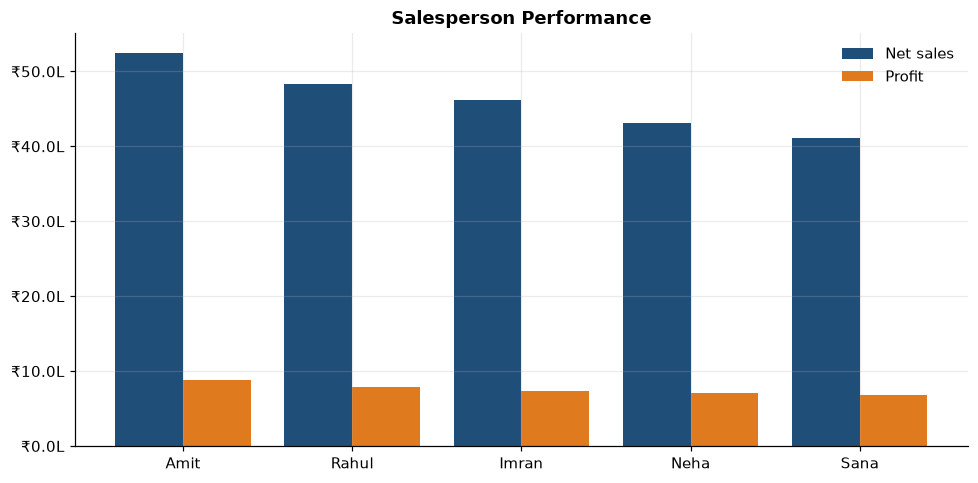

,orders,net_sales,profit,avg_discount_pct,loss_orders,overdue_orders,margin_pct
salesperson,,,,,,,
Amit,264,"5,247,862.04","875,066.07",6.41,6,21,16.67
Rahul,248,"4,835,827.28","791,048.96",5.85,4,24,16.36
Imran,243,"4,621,766.91","738,629.56",6.33,5,25,15.98
Neha,222,"4,311,324.17","705,230.29",6.10,4,29,16.36
Sana,221,"4,104,661.60","678,640.92",6.38,4,27,16.53


In [19]:
sp = (clean.groupby("salesperson")
           .agg(orders=("order_id", "count"), net_sales=("net_sales", "sum"), profit=("profit", "sum"),
                avg_discount_pct=("discount_pct", "mean"), loss_orders=("is_loss", "sum"),
                overdue_orders=("payment_status", lambda s: (s == "Overdue").sum()))
           .sort_values("net_sales", ascending=False))
sp["margin_pct"] = sp["profit"] / sp["net_sales"] * 100

fig, ax = plt.subplots()
x = np.arange(len(sp))
ax.bar(x - 0.2, sp["net_sales"], 0.4, color=PRIMARY, label="Net sales")
ax.bar(x + 0.2, sp["profit"], 0.4, color=ACCENT, label="Profit")
ax.set_xticks(x, sp.index)
ax.yaxis.set_major_formatter(lakh)
ax.set_title("Salesperson Performance")
ax.legend(frameon=False)
save(fig, "05_salesperson")
sp

### 6.8 Payment status & receivables risk

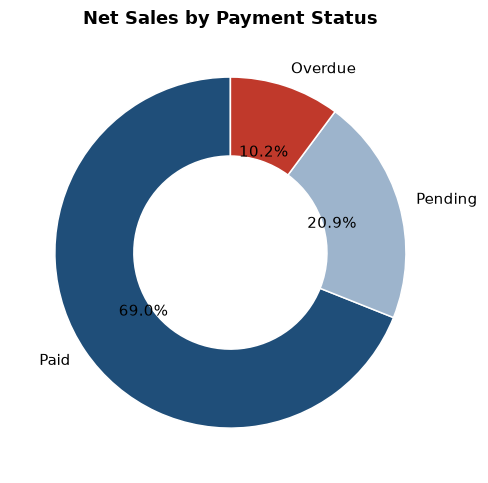

,orders,net_sales,share_pct
payment_status,,,
Paid,823,"15,945,633.87",68.96
Pending,249,"4,827,070.88",20.88
Overdue,126,"2,348,737.25",10.16


Top 10 customers by overdue amount


,,,overdue_orders,overdue_amount
customer_id,customer_name,city,,
C071,Customer 71,Kanpur,3,"108,993.92"
C008,Customer 8,Delhi,4,"106,043.63"
C022,Customer 22,Delhi,3,"99,402.66"
C044,Customer 44,Patna,4,"90,474.54"
C021,Customer 21,Noida,3,"86,728.47"
C067,Customer 67,Varanasi,3,"82,247.46"
C056,Customer 56,Varanasi,3,"81,966.67"
C035,Customer 35,Noida,5,"80,853.46"
C013,Customer 13,Prayagraj,5,"78,310.85"


In [20]:
pay = (clean.groupby("payment_status")
            .agg(orders=("order_id", "count"), net_sales=("net_sales", "sum"))
            .reindex(["Paid", "Pending", "Overdue"]))
pay["share_pct"] = pay["net_sales"] / pay["net_sales"].sum() * 100

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.pie(pay["net_sales"], labels=pay.index, autopct="%1.1f%%", startangle=90,
       colors=[PRIMARY, MUTED, NEG], wedgeprops=dict(width=0.45, edgecolor="white"))
ax.set_title("Net Sales by Payment Status")
save(fig, "06_payment_status")
display(pay)

overdue_cust = (clean[clean["payment_status"] == "Overdue"]
                .groupby(["customer_id", "customer_name", "city"])
                .agg(overdue_orders=("order_id", "count"), overdue_amount=("net_sales", "sum"))
                .sort_values("overdue_amount", ascending=False).head(10))
print("Top 10 customers by overdue amount"); overdue_cust

### 6.9 Discount impact on profitability

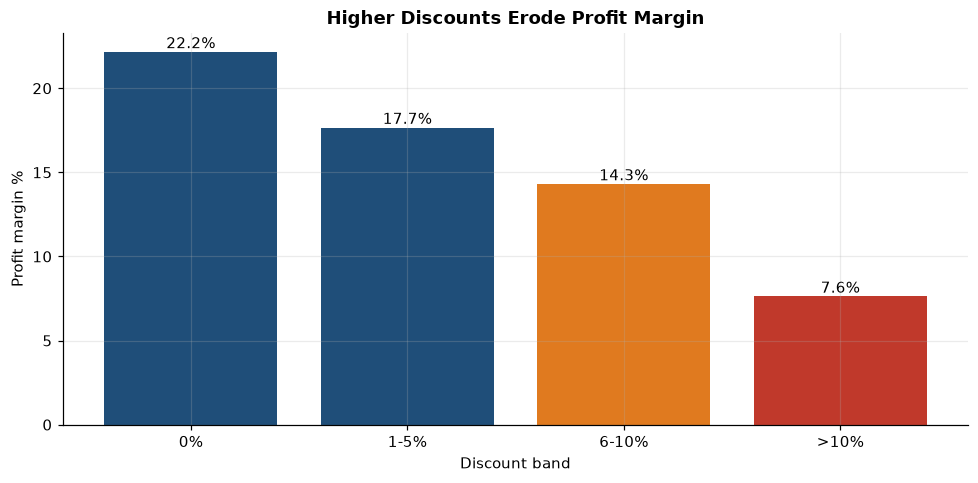

Correlation (discount % vs margin %): -0.528


,orders,net_sales,profit,loss_orders,margin_pct
discount_band,,,,,
0%,184,"3,888,192.04","861,909.89",0,22.17
1-5%,486,"9,511,801.27","1,680,437.19",0,17.67
6-10%,414,"7,551,280.53","1,080,730.46",0,14.31
>10%,114,"2,170,168.16","165,538.26",23,7.63


In [21]:
band_order = ["0%", "1-5%", "6-10%", ">10%"]
disc = (clean.groupby("discount_band")
             .agg(orders=("order_id", "count"), net_sales=("net_sales", "sum"), profit=("profit", "sum"),
                  loss_orders=("is_loss", "sum"))
             .reindex(band_order))
disc["margin_pct"] = disc["profit"] / disc["net_sales"] * 100

fig, ax = plt.subplots()
bars = ax.bar(disc.index, disc["margin_pct"], color=[PRIMARY, PRIMARY, ACCENT, NEG])
ax.bar_label(bars, fmt="%.1f%%")
ax.set_ylabel("Profit margin %"); ax.set_xlabel("Discount band")
ax.set_title("Higher Discounts Erode Profit Margin")
save(fig, "07_discount_margin")
print("Correlation (discount % vs margin %):", round(clean["discount_pct"].corr(clean["profit_margin_pct"]), 3))
disc

### 6.10 Loss-making orders

In [22]:
loss = clean[clean["is_loss"]]
print(f"{len(loss)} loss-making orders, total loss ₹{-loss['profit'].sum():,.0f}")
print("Average discount on loss orders: {:.1f}% vs {:.1f}% overall".format(
      loss["discount_pct"].mean(), clean["discount_pct"].mean()))
loss.groupby(["category"]).agg(orders=("order_id", "count"), loss=("profit", "sum")).sort_values("loss")

23 loss-making orders, total loss ₹13,179
Average discount on loss orders: 15.9% vs 6.2% overall


,orders,loss
category,,
Hardware,7,"-6,422.42"
Paint,6,"-4,944.60"
Safety,3,"-1,686.14"
Electrical,7,-126.16


### 6.11 Quarterly summary

In [23]:
qtr = clean.groupby("quarter").agg(orders=("order_id", "count"), net_sales=("net_sales", "sum"), profit=("profit", "sum"))
qtr["margin_pct"] = qtr["profit"] / qtr["net_sales"] * 100
qtr

,orders,net_sales,profit,margin_pct
quarter,,,,
Q1,285,"5,305,997.86","868,042.79",16.36
Q2,318,"6,320,764.63","1,040,373.73",16.46
Q3,288,"5,447,971.63","873,871.27",16.04
Q4,307,"6,046,707.88","1,006,328.01",16.64


## 7. Key insights & recommendations

### Key insights
1. **Overall performance:** 1,198 valid orders generated **₹2.31 Cr net sales** and **₹37.9 L profit** (16.4% margin) in 2025. ₹15.5 L (6.3% of gross sales) was given away as discounts.
2. **Stable but flat sales:** Monthly net sales range between ₹15.3 L and ₹22.1 L with no clear growth trend. **May** was the best month and **July** the weakest (-25% vs June). Q2 and Q4 were the strongest quarters.
3. **Hardware leads revenue, Plumbing leads margin:** Hardware is 36.6% of sales. Plumbing (19.8%) and Electrical (18.9%) have the best margins. **Safety has only a 9.5% margin**, and Paint (14.6%) is below average.
4. **Discounts drive losses:** Margin falls from **22.2% at 0% discount to 7.6% at >10% discount** (correlation -0.53). **All 23 loss-making orders had discounts above 10%**, averaging 15.9% compared with 6.2% overall.
5. **Weak products:** Product 4 (Hardware) is the 5th-largest product by sales but earns only a 5.6% margin. Products 1, 2 and 18 are also below 8%.
6. **Receivables risk:** **31% of net sales (₹71.8 L) is not yet collected**: ₹48.3 L Pending and **₹23.5 L Overdue**. Overdue amounts are spread across many customers; the top 10 together account for about ₹9 L.
7. **Salespeople:** Amit leads on both sales (₹52.5 L) and margin (16.7%). Neha has the most overdue orders (29), and Imran has the lowest margin (16.0%).
8. **Diversified customer base:** The top 20% of customers contribute only 29% of sales, so there is low dependence on any single customer. Retailers bring in 51% of sales. Varanasi is the top city (₹41.2 L).

### Recommendations
1. **Cap discounts at 10%** without manager approval. Every loss in 2025 came from discounts above that level.
2. **Review pricing of low-margin products** (Product 4, 1, 2 and 18) and of the Safety category, or push higher-margin Plumbing and Electrical products instead.
3. **Run a collections drive** on the ₹23.5 L overdue amount, starting with the top 10 overdue customers. Link part of salesperson incentives to collections.
4. **Fix data capture:** make product and customer IDs mandatory dropdowns (to stop entries like P999 and C999), block quantity ≤ 0, and use a fixed list for payment status.
5. **Plan promotions for slow months** (Feb–Mar, Jul, Sep) to smooth out the sales dips.